In [6]:
import pandas as pd
import numpy as np
import os
import glob
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

os. getcwd()

ModuleNotFoundError: No module named 'matplotlib'

# Extract and clean cannabis policies datasets

### This code cleans data from APIS and from PDAPS

# RML from APIS

Cannabis policy data was donwloaded from here:
https://alcoholpolicy.niaaa.nih.gov/policy-topics/download-policy-topic-data

We obtained variables if the policies were in place as of January 1st of a given year

In [2]:
path=r"../data/1_raw/APIS/firstyear/"

In [3]:
#Loop to rename files and make data cleaning and extraction easier

#volume 1
for year in range(2012, 2025):
    for file in os.listdir(path+str(year)):
        if file.startswith("export--recreational-use-of-cannabis-volume-1"):
            old_filepath = os.path.join(path+str(year), file)
            new_name = str(year)+"_recreational-use-of-cannabis-volume-1.zip"
            new_filepath = os.path.join(path+str(year), new_name)
            os.rename(old_filepath, new_filepath)
#volume 2            
for year in range(2012, 2025):
    for file in os.listdir(path+str(year)):
        if file.startswith("export--recreational-use-of-cannabis-volume-2"):
            old_filepath = os.path.join(path+str(year), file)
            new_name = str(year)+"_recreational-use-of-cannabis-volume-2.zip"
            new_filepath = os.path.join(path+str(year), new_name)
            os.rename(old_filepath, new_filepath)


In [4]:
year = 2013

zf = zipfile.ZipFile(path+str(year)+"/"+str(year)+"_recreational-use-of-cannabis-volume-1.zip") 
df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-1.csv"))

#export-data-csv--recreational-use-of-cannabis-volume-1.csv

print(df.columns)

df.columns = ['statename', 'stateabbr', 'statefips', 'policiesasof',
       'rml', 'regagency', 'productspermitted',
       'cultivationres', 'retailsales_onpremises',
       'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh',
       'localauthority', 'notes1', 'citationscount1', 'citations1',
       'jurisnote1', 'rownote1']
  
df.head()

Index(['Jurisdiction', 'Postal Code', 'FIPS Code', 'Policies as of',
       'Recreational Use Legalized', 'Regulatory Agency', 'Products Permitted',
       'Cultivation Restrictions', 'Retail Sales - On-Premises',
       'Retail Sales - Off-Premises', 'Pricing Controls Imposed',
       'Tax Imposed', 'Underage Prohibitions', 'Impaired Driving Prohibitions',
       'Local Authority', 'Notes', 'Citations Count', 'Citations',
       'Juris Note', 'Row Note'],
      dtype='object')


,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,pricingcontrols,taxes,underageproh,impaireddrivingproh,localauthority,notes1,citationscount1,citations1,jurisnote1,rownote1
0,Alabama,AL,1.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
fp=r"../data/2_intermediate/APIS/firstyear/"

In [6]:
# Loop for years 2012-2021

#vol1 policies
for year in range(2013, 2025):
    zf = zipfile.ZipFile(path+str(year)+"/"+str(year)+"_recreational-use-of-cannabis-volume-1.zip") 
    df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-1.csv"))
    df.columns = ['statename', 'stateabbr', 'statefips', 'policiesasof',
       'rml', 'regagency', 'productspermitted',
       'cultivationres', 'retailsales_onpremises',
       'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh',
       'localauthority', 'notes1', 'citationscount1', 'citations1',
       'jurisnote1', 'rownote1']
    df["year"] = year
    df.to_csv(fp+"vol1_"+str(year)+".csv", index=False)
    

#vol2 policies
for year in range(2013, 2025):
    zf = zipfile.ZipFile(path+str(year)+"/"+str(year)+"_recreational-use-of-cannabis-volume-2.zip") 
    df = pd.read_csv(zf.open("export-data-csv--recreational-use-of-cannabis-volume-2.csv"))
    df.columns = ['statename', 'stateabbr', 'statefips','policiesasof', 'rml', 'vertprohibited', 
                  'industrymakeup', 'trackingreq', 'pesticides', 'warningreq', 'packagingreq', 
                  'advertising_youth', 'advertising_gen', 'publicuse', 'homedelivery', 
                  'opencontainer', 'notes2', 'citationscount2', 'citations2', 'jurisnote2',
                  'rownote2']
    df["year"] = year
    df.to_csv(fp+"vol2_"+str(year)+".csv", index=False)

In [7]:
# Example from here: https://java2blog.com/merge-multiple-csv-files-python/
#import pandas as pd
#files = ['file1.csv', 'file2.csv']
#df = pd.DataFrame()
#for file in files:
#    data = pd.read_csv(file)
#    df = pd.concat([df, data], axis=0)
#df.to_csv('merged_files.csv', index=False)


#merge all years of vol1 cannabis policies
files = ['vol1_2013.csv', 'vol1_2014.csv', 'vol1_2015.csv', 'vol1_2016.csv', 
         'vol1_2017.csv', 'vol1_2018.csv' , 'vol1_2019.csv', 'vol1_2020.csv', 'vol1_2021.csv',        
         'vol1_2022.csv', 'vol1_2023.csv', 'vol1_2024.csv']

df = pd.DataFrame()

for file in files:
    data = pd.read_csv(fp+file)
    df = pd.concat([df,data], axis=0)
df.to_csv(fp+'merged_vol1_2013_2024.csv', index=False)

#merge all years of vol2 cannabis policies
files = ['vol2_2013.csv', 'vol2_2014.csv', 'vol2_2015.csv', 'vol2_2016.csv', 
         'vol2_2017.csv', 'vol2_2018.csv' , 'vol2_2019.csv', 'vol2_2020.csv', 'vol2_2021.csv',
         'vol2_2022.csv', 'vol2_2023.csv', 'vol2_2024.csv']

df = pd.DataFrame()

for file in files:

    data = pd.read_csv(fp+file)
    df = pd.concat([df, data], axis=0)
df.to_csv(fp+'merged_vol2_2013_2024.csv', index=False)

In [8]:
df1 = pd.read_csv(fp+'merged_vol1_2013_2024.csv')
df2 = pd.read_csv(fp+'merged_vol2_2013_2024.csv')

cannabispol = pd.merge(df1, df2, how='inner', on=['statename', 'stateabbr', 'statefips', 
                                                  'policiesasof', 'rml', 'year'])

cannabispol.to_csv(fp+"cannabispol_2013_2024.csv", index=False)

In [9]:
cannabispol.head()

,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,...,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer,notes2,citationscount2,citations2,jurisnote2,rownote2
0,Alabama,AL,1.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print(cannabispol.columns)

Index(['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml',
       'regagency', 'productspermitted', 'cultivationres',
       'retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh', 'localauthority',
       'notes1', 'citationscount1', 'citations1', 'jurisnote1', 'rownote1',
       'year', 'vertprohibited', 'industrymakeup', 'trackingreq', 'pesticides',
       'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
       'publicuse', 'homedelivery', 'opencontainer', 'notes2',
       'citationscount2', 'citations2', 'jurisnote2', 'rownote2'],
      dtype='object')


In [11]:
cannabispol

,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,...,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer,notes2,citationscount2,citations2,jurisnote2,rownote2
0,Alabama,AL,1.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,Washington,WA,53.0,1/1/2024,1,Washington State Liquor and Cannabis Board,Herbal; Edibles & Infused Products; Tinctures;...,"3 license tiers, with cultivation limits rangi...",No,Yes – License Required,...,Both,Both,Prohibited,Prohibited,Prohibited,Row Note: \n\n Vertical Integration...,15 Citations,EB: Wash. Initiative Measure No. 502 (2012)\n\...,NaN,Vertical Integration Prohibited:\n\nNeither a ...
620,West Virginia,WV,54.0,1/1/2024,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
621,Wisconsin,WI,55.0,1/1/2024,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
622,Wyoming,WY,56.0,1/1/2024,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
cannabispol['stateabbr'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY', 'US'], dtype=object)

In [13]:
pd.crosstab(cannabispol['year'], cannabispol['regagency'])

regagency,"Alcohol,Tobacco,andCannabisCommission; Maryland Cannabis Administration",Bureau of Cannabis Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health,Bureau of Marijuana Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health,Cannabis Compliance Board,Cannabis Control Board,"Cannabis Control Board\nThe Agency of Agriculture, Food and Markets",Cannabis Control Board; Officeof Cannabis Management,Cannabis Control Commission,Cannabis Control Division,"Cannabis Regulatory Agency, Department of Licensing and Regulatory Affairs",...,Marijuana Control Board,"Marijuana Enforcement Division, Department of Revenue","Marijuana Regulatory Agency, Department of Licensing and Regulatory Affairs",Office of Cannabis Management,Oregon Liquor Control Commission,Oregon Liquor and Cannabis Commission,The Division of Alcohol and Tobacco Enforcement of the Department of Safety and Homeland Security,Virginia Cannabis Control Authority,Washington State Liquor Board,Washington State Liquor and Cannabis Board
year,,,,,,,,,,,,,,,,,,,,,
2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2014,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2015,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2016,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,1
2017,0,0,1,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,1
2018,0,1,0,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,1
2019,0,1,0,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0,0,0,1
2020,0,1,0,0,0,0,0,1,0,0,...,1,1,1,0,1,0,0,0,0,1
2021,0,1,0,1,0,1,0,1,0,0,...,1,1,1,0,1,0,0,0,0,1


In [14]:
cannabispol['regagency'].value_counts()

regagency
Marijuana Enforcement Division, Department of Revenue                                                                                                                                                          11
Washington State Liquor and Cannabis Board                                                                                                                                                                     10
Cannabis Control Commission                                                                                                                                                                                    10
Marijuana Control Board                                                                                                                                                                                         9
Bureau of Cannabis Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health                           

In [15]:
cannabispol['regagency'].unique()

array([nan, 'Department of Revenue', 'Washington State Liquor Board',
       'Marijuana Enforcement Division, Department of Revenue',
       'Washington State Liquor and Cannabis Board',
       'Marijuana Control Board', 'Oregon Liquor Control Commission',
       'Bureau of Marijuana Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health',
       'Cannabis Control Commission', 'Department of Taxation',
       'Bureau of Cannabis Control; Department of Consumer Affairs; Department of Food and Agriculture; Department of Public Health',
       'Department of Administrative and Financial Services',
       'Department of Licensing and Regulatory Affairs',
       'Department of Agriculture; Department of Commerce and Economic Opportunity; Department of State Police; Department of Financial and Professional Regulation; Department of Revenue; Office of the Treasurer',
       'Marijuana Regulatory Agency, Department of Licensing and Regulatory A

In [16]:
result=cannabispol.groupby('year')['regagency'].apply(list).to_dict()

In [17]:
print(cannabispol.columns)

Index(['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml',
       'regagency', 'productspermitted', 'cultivationres',
       'retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh', 'localauthority',
       'notes1', 'citationscount1', 'citations1', 'jurisnote1', 'rownote1',
       'year', 'vertprohibited', 'industrymakeup', 'trackingreq', 'pesticides',
       'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
       'publicuse', 'homedelivery', 'opencontainer', 'notes2',
       'citationscount2', 'citations2', 'jurisnote2', 'rownote2'],
      dtype='object')


In [18]:
cannabis_subset = cannabispol[['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml', 'regagency', 'productspermitted', 
                               'cultivationres','retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols', 'taxes', 
                               'underageproh', 'impaireddrivingproh', 'localauthority', 'year', 'vertprohibited', 
                               'industrymakeup', 'trackingreq', 'pesticides', 'warningreq', 'packagingreq', 'advertising_youth', 
                               'advertising_gen', 'publicuse', 'homedelivery', 'opencontainer']]

In [19]:
cannabis_subset.head()

,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,...,industrymakeup,trackingreq,pesticides,warningreq,packagingreq,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer
0,Alabama,AL,1.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#Remove if state abbreviation is US
cannabis_subset = cannabis_subset.drop(cannabis_subset[cannabis_subset['statename'] == 'United States'].index)

In [21]:
for col in cannabis_subset:
    print(cannabis_subset[col].unique())

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']
['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'HI' 'ID' 'IL'
 'IN' 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE'
 'NV' 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']
[ 1.  2.  4.  5.  6.  8.  9. 10. 11. 12. 13. 15. 16. 17. 18. 19. 20. 21.
 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 3

In [22]:
print(cannabis_subset.columns)


Index(['statename', 'stateabbr', 'statefips', 'policiesasof', 'rml',
       'regagency', 'productspermitted', 'cultivationres',
       'retailsales_onpremises', 'retailsales_offpremises', 'pricingcontrols',
       'taxes', 'underageproh', 'impaireddrivingproh', 'localauthority',
       'year', 'vertprohibited', 'industrymakeup', 'trackingreq', 'pesticides',
       'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
       'publicuse', 'homedelivery', 'opencontainer'],
      dtype='object')


In [23]:
cannabis_subset.describe(include='all').loc['unique', :]

statename                   51
stateabbr                   51
statefips                  NaN
policiesasof                12
rml                        NaN
regagency                   30
productspermitted            6
cultivationres              34
retailsales_onpremises       2
retailsales_offpremises      2
pricingcontrols            NaN
taxes                       32
underageproh                 5
impaireddrivingproh          9
localauthority               2
year                       NaN
vertprohibited             NaN
industrymakeup               1
trackingreq                NaN
pesticides                   4
warningreq                  16
packagingreq                12
advertising_youth            3
advertising_gen              3
publicuse                    2
homedelivery                 4
opencontainer                2
Name: unique, dtype: object

In [24]:
cannabis_subset.astype('object').describe(include='all').loc['unique', :]

statename                    51
stateabbr                    51
statefips                  51.0
policiesasof                 12
rml                           2
regagency                    30
productspermitted             6
cultivationres               34
retailsales_onpremises        2
retailsales_offpremises       2
pricingcontrols               2
taxes                        32
underageproh                  5
impaireddrivingproh           9
localauthority                2
year                         12
vertprohibited                2
industrymakeup                1
trackingreq                   2
pesticides                    4
warningreq                   16
packagingreq                 12
advertising_youth             3
advertising_gen               3
publicuse                     2
homedelivery                  4
opencontainer                 2
Name: unique, dtype: object

In [25]:
for col in cannabis_subset:
    print(col)
    print(cannabis_subset[col].unique())
    print('\n')

statename
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


stateabbr
['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'HI' 'ID' 'IL'
 'IN' 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE'
 'NV' 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']


statefips
[ 1.  2.  4.  5.  6.  8.  9. 10. 11. 12. 13. 15. 16. 17. 18. 19. 20. 21.
 22. 23. 24. 25. 26. 27. 28.

In [26]:
df_len = len(cannabis_subset)
unique_cols_list = []
for col in cannabis_subset:
    try:
        unique_values = cannabis_subset[col].unique()
        unique_len = len(unique_values)
    except TypeError:  # not all cols are hashable
        unique_values = ""
        unique_len = -1
    perc_unique = unique_len*100/df_len
    unique_cols_list.append((col, unique_len, df_len, perc_unique, unique_values))
df_unique_cols = pd.DataFrame(unique_cols_list, columns=["col", "unique_len", "df_len", "perc_unique", "unique_values"])
df_unique_cols = df_unique_cols[df_unique_cols["unique_len"] > 0].sort_values("unique_len", ascending=False)
print(df_unique_cols)

                        col  unique_len  df_len  perc_unique  \
0                 statename          51     612     8.333333   
2                 statefips          51     612     8.333333   
1                 stateabbr          51     612     8.333333   
7            cultivationres          35     612     5.718954   
11                    taxes          33     612     5.392157   
5                 regagency          31     612     5.065359   
20               warningreq          17     612     2.777778   
21             packagingreq          13     612     2.124183   
3              policiesasof          12     612     1.960784   
15                     year          12     612     1.960784   
13      impaireddrivingproh          10     612     1.633987   
6         productspermitted           7     612     1.143791   
12             underageproh           6     612     0.980392   
19               pesticides           5     612     0.816993   
25             homedelivery           5 

In [27]:
df_unique_cols.to_csv(fp+"cannabispol_2013_2024_dict.csv", index=False)

In [28]:
cross_tab = pd.crosstab(cannabis_subset['year'], cannabis_subset['rml'])

In [29]:
cannabis_subset['rml'].unique()

array([0, 1], dtype=int64)

In [30]:
cross_tab

rml,0,1
year,,
2013,49,2
2014,49,2
2015,49,2
2016,46,5
2017,43,8
2018,42,9
2019,40,11
2020,39,12
2021,36,15


Text(0.5, 1.0, 'RCL by year')

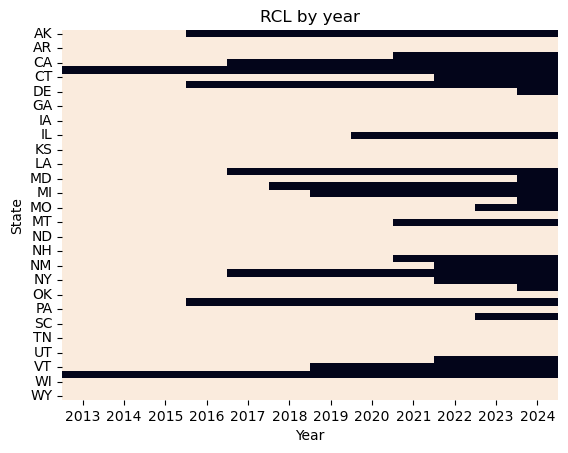

In [31]:
# Draw a heatmap with the numeric values in each cell

rml = cannabis_subset.pivot(index = "stateabbr", columns = "year", values = "rml")
cmap = sns.cm.rocket_r
ax = sns.heatmap(rml, cmap=cmap, cbar=False)
ax.set(xlabel='Year', ylabel='State')
plt.title('RCL by year')

In [32]:
cannabis_subset.to_csv(fp+"cannabispol_subset_2012_2024.csv", index=False)

In [33]:
regagency = pd.pivot_table(cannabis_subset, values='regagency', index='stateabbr', columns='year', aggfunc='first')

regagency

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board,Marijuana Control Board
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Department of Health Services; Department of R...,Department of Health Services; Department of R...,Department of Health Services; Department of R...,Department of Health Services; Department of R...
CA,NaN,NaN,NaN,NaN,Bureau of Marijuana Control; Department of Con...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...,Bureau of Cannabis Control; Department of Cons...
CO,Department of Revenue,"Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ...","Marijuana Enforcement Division, Department of ..."
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Department of Consumer Protection,Department of Consumer Protection,Department of Consumer Protection
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The Division of Alcohol and Tobacco Enforcemen...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Department of Agriculture; Department of Comme...,Department of Agriculture; Department of Comme...,Department of Agriculture; Department of Comme...,Department of Agriculture; Department of Comme...,Department of Agriculture; Department of Comme...
MA,NaN,NaN,NaN,NaN,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission,Cannabis Control Commission
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Alcohol,Tobacco,andCannabisCommission; Marylan..."


In [34]:
taxes = pd.pivot_table(cannabis_subset, values='taxes', index='stateabbr', columns='year', aggfunc='first')

taxes

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,$50 per oz. (producer-level),"$50 per oz. any part of bud/flower, $15 per oz...","$50 per oz. any part of bud/flower, $15 per oz...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b...","$50 per oz. mature bud, $25 per oz. immature b..."
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16% cannabis excise tax (retail-level),16% cannabis excise tax (retail-level),16% cannabis excise tax (retail-level),16% cannabis excise tax (retail-level)
CA,NaN,NaN,NaN,NaN,$9.25 per oz. flowers; $2.75 per oz. leaves (p...,$9.25 per oz. flowers; $2.75 per oz. leaves; $...,$9.25 per oz. flowers; $2.75 per oz. leaves; $...,$9.65 per oz. flowers; $2.87 per oz. leaves; $...,$9.65 per oz. flowers; $2.87 per oz. leaves; $...,$10.08 per oz. flowers; $3.00 per oz. leaves; ...,15% of sales (retail-level),15% of sales (retail-level)
CO,15% of sales (producer-level),15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 10% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...,15% of sales (producer-level); 15% of sales (r...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$0.00625 per mg of total THC for cannabis plan...,$0.00625 per mg of total THC for cannabis plan...,$0.00625 per mg of total THC for cannabis plan...
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15% of sales (retail level)
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7% of gross receipts (producer-level); 10% for...,7% of gross receipts (producer-level); 10% for...,7% of gross receipts (producer-level); 10% for...,7% of gross receipts (producer-level); 10% for...,7% of gross receipts (producer-level); 10% for...
MA,NaN,NaN,NaN,NaN,3.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level),10.75% of sales (retail-level)
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9% (retail level)


In [35]:
cultivationres = pd.pivot_table(cannabis_subset, values='cultivationres', index='stateabbr', columns='year', aggfunc='first')

cultivationres

year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,
AK,NaN,NaN,NaN,<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note),<500 sq ft for “limited” licenses (see note)
CA,NaN,NaN,NaN,"13 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang...","14 license types, with cultivation limits rang..."
CO,NaN,"3,600 plants","1,800 plants","1,800 plants","1,800 plants","1,800 plants","1,800 plants","5 tiers of licenses, nocap on max plant count","5 tiers of licenses, nocap on max plant count","5 tiers of licenses, nocap on max plant count","5 tiers of licenses, nocap on max plant count"
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Micro-cultivators >= 2000 sq ft which can be i...,"Micro-cultivators >= 2,000 sq ft to 10,000 sq ...","Micro-cultivators >= 2,000 sq ft to 10,000 sq ..."
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Four tiers of licensing with indoor limits ran...
IL,NaN,NaN,NaN,NaN,NaN,NaN,"Cultivation Centers <=210,000 sqft; Craft Grow...","Cultivation Centers <=210,000 sqft; Craft Grow...","Cultivation Centers <=210,000 sqft; Craft Grow...","Cultivation Centers <=210,000 sqft; Craft Grow...","Cultivation Centers <=210,000 sqft; Craft Grow..."
MA,NaN,NaN,NaN,NaN,NaN,"11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t...","11 license tiers, with cultivation limits up t..."
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A standard license authorizes growers to opera...
ME,NaN,NaN,NaN,NaN,"2 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi...","5 license types, with cultivation limits rangi..."


In [36]:
warningreq = pd.pivot_table(cannabis_subset, values='warningreq', index='stateabbr', columns='year', aggfunc='first')

warningreq

year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,
AK,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Child Access; Impairment of Dri...,Amount of THC; Child Access; Impairment of Dri...,Amount of THC; Child Access; Impairment of Dri...
CA,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
CO,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
IL,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Impairment of Dr...,Amount of THC; Breastfeeding; Impairment of Dr...,Amount of THC; Breastfeeding; Impairment of Dr...,Amount of THC; Breastfeeding; Impairment of Dr...,Amount of THC; Breastfeeding; Impairment of Dr...
MA,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amount of THC; Breastfeeding; Child Access; Im...
ME,NaN,NaN,NaN,NaN,Amount of THC; Presence of Cannabis or THC; Se...,Amount of THC; Presence of Cannabis or THC; Se...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...,Amount of THC; Breastfeeding; Child Access; Im...


In [37]:
packagingreq = pd.pivot_table(cannabis_subset, values='packagingreq', index='stateabbr', columns='year', aggfunc='first')

packagingreq

year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,
AK,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other
CA,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...
CO,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size,Child-Proof/Resistant; Serving Size
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...
IL,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other,Child-Proof/Resistant; Serving Size; Other
MA,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...,Child-Proof/Resistant; Serving Size; Tamper-Pr...
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Ev...
ME,NaN,NaN,NaN,NaN,NaN,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...,Child-Proof/Resistant; Serving Size; Tamper-Ev...


In [38]:
impaireddrivingproh = pd.pivot_table(cannabis_subset, values='impaireddrivingproh', index='stateabbr', columns='year', aggfunc='first')

impaireddrivingproh

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
CA,NaN,NaN,NaN,NaN,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...
CO,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
DC,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...
MA,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...


In [39]:
impaireddrivingproh = pd.pivot_table(cannabis_subset, values='impaireddrivingproh', index='stateabbr', columns='year', aggfunc='first')

impaireddrivingproh

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
CA,NaN,NaN,NaN,NaN,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...,Adult: No specific prohibition\nYouth: No spec...
CO,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...,Adult: Prohibited - 5 ng/mL limit (not per se)...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
DC,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...,Adult: Prohibited - 5 ng/mL limit (per se) blo...
MA,NaN,NaN,NaN,NaN,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...,Adult: Prohibited - THC limit and evidentiary ...


In [40]:
productspermitted = pd.pivot_table(cannabis_subset, values='productspermitted', index='stateabbr', columns='year', aggfunc='first')

productspermitted

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
CA,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Concentrates,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
CO,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
DC,NaN,NaN,NaN,Herbal,Herbal,Herbal,Herbal,Herbal,Herbal,Herbal,Herbal,Herbal
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...
MA,NaN,NaN,NaN,NaN,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...,Herbal; Edibles & Infused Products; Tinctures;...


In [41]:
underageproh = pd.pivot_table(cannabis_subset, values='underageproh', index='stateabbr', columns='year', aggfunc='first')

underageproh


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
CA,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
CO,Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
DC,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing
MA,NaN,NaN,NaN,NaN,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing,Purchase; Possession; Consumption; Furnishing


In [42]:
pesticides = pd.pivot_table(cannabis_subset, values='pesticides', index='stateabbr', columns='year', aggfunc='first')

pesticides


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
CA,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
CO,No Law,Restricted,Restricted,Restricted,Restricted,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
MA,NaN,NaN,NaN,NaN,No Law,Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Restricted; Testing Required
ME,NaN,NaN,NaN,NaN,NaN,Testing Required,Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required,Restricted; Testing Required


In [43]:
advertising_gen = pd.pivot_table(cannabis_subset, values='advertising_gen', index='stateabbr', columns='year', aggfunc='first')

advertising_gen



year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both,Both,Both
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Content,Content,Content,Content
CA,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both,Both,Both
CO,NaN,Both,Both,Both,Both,Both,Both,Both,Both,Both,Both,Both
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both
MA,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both
ME,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both


In [44]:
homedelivery = pd.pivot_table(cannabis_subset, values='homedelivery', index='stateabbr', columns='year', aggfunc='first')

homedelivery


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited
CA,NaN,NaN,NaN,NaN,Allowed,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
CO,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
DC,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,No Law,No Law,Prohibited,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions


In [45]:
advertising_youth = pd.pivot_table(cannabis_subset, values='homedelivery', index='stateabbr', columns='year', aggfunc='first')

advertising_youth


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited
CA,NaN,NaN,NaN,NaN,Allowed,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
CO,No Law,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions
DC,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,No Law,No Law,Prohibited,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions,Allowed with Restrictions


In [46]:
retailsales_offpremises = pd.pivot_table(cannabis_subset, values='retailsales_offpremises', index='stateabbr', columns='year', aggfunc='first')

retailsales_offpremises

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
CA,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
CO,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required
DC,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
MA,NaN,NaN,NaN,NaN,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required


In [32]:
localauthority = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='localauthority', index='stateabbr', columns='year', aggfunc='first')

localauthority


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both,Both,Both,Both
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both
CA,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both,Both,Both
CO,Both,Both,Both,Both,Both,Both,Both,Both,Both,Both,Both,Both
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both
MA,NaN,NaN,NaN,NaN,Both,Both,Both,Both,Both,Both,Both,Both
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Local Control


In [33]:
retailsales_onpremises = pd.pivot_table(cannabis_subset, values='retailsales_onpremises', index='stateabbr', columns='year', aggfunc='first')

retailsales_onpremises


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,No,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,No
CA,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No
CO,No,No,No,No,No,No,No,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No
DC,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,No,No
MA,NaN,NaN,NaN,NaN,No,No,No,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required,Yes – License Required


In [34]:
publicuse = pd.pivot_table(cannabis_subset, values='publicuse', index='stateabbr', columns='year', aggfunc='first')

publicuse


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Prohibited,Restricted,Restricted,Restricted,Restricted,Restricted,Restricted,Restricted,Restricted
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited
CA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
CO,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Restricted,Restricted,Restricted,Restricted,Restricted
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited
DC,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Restricted,Restricted,Restricted,Restricted,Restricted


In [35]:
opencontainer = pd.pivot_table(cannabis_subset, values='opencontainer', index='stateabbr', columns='year', aggfunc='first')

opencontainer


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Law,No Law,No Law,No Law
CA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
CO,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited
DC,NaN,NaN,NaN,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law,No Law
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Law
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited
MA,NaN,NaN,NaN,NaN,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited,Prohibited


In [36]:
pricingcontrols = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='pricingcontrols', index='stateabbr', columns='year', aggfunc='first')

pricingcontrols

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
CA,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CO,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
DC,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
MA,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
print(cannabis_subset['pricingcontrols'].dtype)

int64


In [38]:
vertprohibited = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='vertprohibited', index='stateabbr', columns='year', aggfunc='first')

vertprohibited

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
CA,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
DC,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
MA,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
industrymakeup = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='industrymakeup', index='stateabbr', columns='year', aggfunc='first')

industrymakeup


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities
CA,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
CO,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
MA,NaN,NaN,NaN,NaN,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities,Private Entities
MD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Private Entities


In [40]:
trackingreq = pd.pivot_table(cannabis_subset[cannabis_subset.rml == 1], values='trackingreq', index='stateabbr', columns='year', aggfunc='first')

trackingreq

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
stateabbr,,,,,,,,,,,,
AK,NaN,NaN,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
AZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,1.0
CA,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CO,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
DC,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
MA,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


In [41]:
cannabispol_all = cannabispol.drop(cannabispol[cannabispol['statename'] == 'United States'].index)

cannabispol_all

,statename,stateabbr,statefips,policiesasof,rml,regagency,productspermitted,cultivationres,retailsales_onpremises,retailsales_offpremises,...,advertising_youth,advertising_gen,publicuse,homedelivery,opencontainer,notes2,citationscount2,citations2,jurisnote2,rownote2
0,Alabama,AL,1.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,AK,2.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arizona,AZ,4.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arkansas,AR,5.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,6.0,1/1/2013,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,Virginia,VA,51.0,1/1/2024,1,Virginia Cannabis Control Authority,Herbal; Edibles & Infused Products; Tinctures;...,NaN,No,Yes – License Required,...,NaN,NaN,Prohibited,No Law,No Law,Row Note: \n\n Recreational Use Leg...,9 Citations,"EB: 2022 Virginia Acts 1st Sp. Sess. ch. 2, cl...",NaN,Recreational Use Legalized:\n\nHB 2312 and SB ...
619,Washington,WA,53.0,1/1/2024,1,Washington State Liquor and Cannabis Board,Herbal; Edibles & Infused Products; Tinctures;...,"3 license tiers, with cultivation limits rangi...",No,Yes – License Required,...,Both,Both,Prohibited,Prohibited,Prohibited,Row Note: \n\n Vertical Integration...,15 Citations,EB: Wash. Initiative Measure No. 502 (2012)\n\...,NaN,Vertical Integration Prohibited:\n\nNeither a ...
620,West Virginia,WV,54.0,1/1/2024,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
621,Wisconsin,WI,55.0,1/1/2024,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
#Create a stata file
cannabis_subset.to_stata(fp+"cannabispol_2013_2024.dta", version=118)


In [43]:
non_str_cols = cannabispol_all.select_dtypes(exclude=['number', 'string']).columns
print(non_str_cols)


Index(['statename', 'stateabbr', 'policiesasof', 'regagency',
       'productspermitted', 'cultivationres', 'retailsales_onpremises',
       'retailsales_offpremises', 'taxes', 'underageproh',
       'impaireddrivingproh', 'localauthority', 'notes1', 'citationscount1',
       'citations1', 'jurisnote1', 'rownote1', 'industrymakeup', 'pesticides',
       'warningreq', 'packagingreq', 'advertising_youth', 'advertising_gen',
       'publicuse', 'homedelivery', 'opencontainer', 'notes2',
       'citationscount2', 'citations2', 'rownote2'],
      dtype='object')


In [44]:
#Allvars
cannabispol_all.to_csv(fp+"cannabispol_all_2013_2024.csv", index=False)

# Add MCL from PDAPs

PDAPS dataset only available from September 2014 through February 2017

Data were obtained from: 

- Patients: https://pdaps.org/datasets/medical-marijuana-patient-related-laws-1501600783
- Product safety: https://pdaps.org/datasets/product-safety-medical-marijuana-1501612211
- Dispensaries: https://pdaps.org/datasets/dispensaries-medical-marijuana-1501611712


## Add variables from the patients dataset

In [60]:
pat = pd.read_excel(r"..\data\1_raw\PDAPS\20170919.MM.Patients.Stat.Data.xlsx")

In [61]:
pat

,Jurisdictions,Effective Date,Valid Through Date,mmlaw,mmban,date-first-law,mmqdx_Arthritis,mmqdx_Post-Traumatic Stress Disorder,mmqdx_Cancer,mmqdx_Glaucoma,...,mmshield_Education,mmaffd,mmins,mmsubsid,mmqsub_Low income residents,mmqsub_Medicare participants,mmqsub_Medicaid participants,mmqsub_Homeless residents,mmsubmet_Fee waivers,mmsubmet_Cost is based on income
0,Alabama,2014-01-01,2017-02-01,0,.,NaN,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
1,Alaska,2010-06-10,2017-02-01,1,0,1999-03-04 00:00:00,0,0,1,1,...,.,1,1,0,.,.,.,.,.,.
2,Arizona,2011-04-14,2012-08-01,1,0,2010-12-14 00:00:00,0,0,1,1,...,1,1,1,1,1,0,0,0,1,0
3,Arizona,2012-08-02,2012-12-04,1,0,2010-12-14 00:00:00,0,0,1,1,...,1,1,1,1,1,0,0,0,1,0
4,Arizona,2012-12-05,2015-07-02,1,0,2010-12-14 00:00:00,0,0,1,1,...,1,1,1,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Washington,2015-07-24,2016-06-30,1,0,1998-12-03 00:00:00,0,0,1,1,...,0,1,1,0,.,.,.,.,.,.
184,Washington,2016-07-01,2017-02-01,1,0,1998-12-03 00:00:00,0,1,1,1,...,0,1,1,0,.,.,.,.,.,.
185,West Virginia,2014-01-01,2017-02-01,0,.,NaN,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
186,Wisconsin,2014-01-01,2017-02-01,0,.,NaN,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.


In [62]:
pat.columns

Index(['Jurisdictions', 'Effective Date', 'Valid Through Date', 'mmlaw',
       'mmban', 'date-first-law', 'mmqdx_Arthritis',
       'mmqdx_Post-Traumatic Stress Disorder', 'mmqdx_Cancer',
       'mmqdx_Glaucoma',
       ...
       'mmshield_Education', 'mmaffd', 'mmins', 'mmsubsid',
       'mmqsub_Low income residents', 'mmqsub_Medicare participants',
       'mmqsub_Medicaid participants', 'mmqsub_Homeless residents',
       'mmsubmet_Fee waivers', 'mmsubmet_Cost is based on income'],
      dtype='object', length=120)

In [63]:
pat['start_date'] = pd.to_datetime(pat['Effective Date'])
pat['end_date'] = pd.to_datetime(pat['Valid Through Date'])

In [64]:
pat.columns

Index(['Jurisdictions', 'Effective Date', 'Valid Through Date', 'mmlaw',
       'mmban', 'date-first-law', 'mmqdx_Arthritis',
       'mmqdx_Post-Traumatic Stress Disorder', 'mmqdx_Cancer',
       'mmqdx_Glaucoma',
       ...
       'mmins', 'mmsubsid', 'mmqsub_Low income residents',
       'mmqsub_Medicare participants', 'mmqsub_Medicaid participants',
       'mmqsub_Homeless residents', 'mmsubmet_Fee waivers',
       'mmsubmet_Cost is based on income', 'start_date', 'end_date'],
      dtype='object', length=122)

In [65]:
pat

,Jurisdictions,Effective Date,Valid Through Date,mmlaw,mmban,date-first-law,mmqdx_Arthritis,mmqdx_Post-Traumatic Stress Disorder,mmqdx_Cancer,mmqdx_Glaucoma,...,mmins,mmsubsid,mmqsub_Low income residents,mmqsub_Medicare participants,mmqsub_Medicaid participants,mmqsub_Homeless residents,mmsubmet_Fee waivers,mmsubmet_Cost is based on income,start_date,end_date
0,Alabama,2014-01-01,2017-02-01,0,.,NaN,.,.,.,.,...,.,.,.,.,.,.,.,.,2014-01-01,2017-02-01
1,Alaska,2010-06-10,2017-02-01,1,0,1999-03-04 00:00:00,0,0,1,1,...,1,0,.,.,.,.,.,.,2010-06-10,2017-02-01
2,Arizona,2011-04-14,2012-08-01,1,0,2010-12-14 00:00:00,0,0,1,1,...,1,1,1,0,0,0,1,0,2011-04-14,2012-08-01
3,Arizona,2012-08-02,2012-12-04,1,0,2010-12-14 00:00:00,0,0,1,1,...,1,1,1,0,0,0,1,0,2012-08-02,2012-12-04
4,Arizona,2012-12-05,2015-07-02,1,0,2010-12-14 00:00:00,0,0,1,1,...,1,1,1,0,0,0,1,0,2012-12-05,2015-07-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Washington,2015-07-24,2016-06-30,1,0,1998-12-03 00:00:00,0,0,1,1,...,1,0,.,.,.,.,.,.,2015-07-24,2016-06-30
184,Washington,2016-07-01,2017-02-01,1,0,1998-12-03 00:00:00,0,1,1,1,...,1,0,.,.,.,.,.,.,2016-07-01,2017-02-01
185,West Virginia,2014-01-01,2017-02-01,0,.,NaN,.,.,.,.,...,.,.,.,.,.,.,.,.,2014-01-01,2017-02-01
186,Wisconsin,2014-01-01,2017-02-01,0,.,NaN,.,.,.,.,...,.,.,.,.,.,.,.,.,2014-01-01,2017-02-01


In [66]:
def generate_dates(row):
    return pd.date_range(start=row['start_date'], end=row['end_date'])

In [67]:
pat_expanded_rows = []
for _, row in pat.iterrows():
    dates = generate_dates(row)
    for date in dates:
        pat_expanded_rows.append({
            'State': row['Jurisdictions'],
            'Date': date,
            'mml_1stlaw': row["date-first-law"],
            'mmlaw': row["mmlaw"],
            'mml_minors_auth': row['mmminors'],
            'mml_minors_guardianappr': row['mmminot_Legal Guardian approval'],
            'mml_minors_guardiancontrol': row['mmminot_Legal guardian control of possession, dosage, and frequency of usage'],
            'mml_pos_limits': row['mmlimu'], #Q82 How much is marijuana may a cardholder possess
            'mml_cult_allowed': row['mmcult'], #Q83 Is cultivation allowed
            'mml_cult_limits': row['mmcultlim'],  #Q84 Plants may a patient legally cultivate
            'mml_use_proh': row['mmuseban_No use prohibitions in the law'] #Q99 No use prohibitions in the law
        })

In [68]:
pat_longitudinal_df = pd.DataFrame(pat_expanded_rows)

In [69]:
pat_longitudinal_df

,State,Date,mml_1stlaw,mmlaw,mml_minors_auth,mml_minors_guardianappr,mml_minors_guardiancontrol,mml_pos_limits,mml_cult_allowed,mml_cult_limits,mml_use_proh
0,Alabama,2014-01-01,NaN,0,.,.,.,.,.,.,.
1,Alabama,2014-01-02,NaN,0,.,.,.,.,.,.,.
2,Alabama,2014-01-03,NaN,0,.,.,.,.,.,.,.
3,Alabama,2014-01-04,NaN,0,.,.,.,.,.,.,.
4,Alabama,2014-01-05,NaN,0,.,.,.,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...
69533,Wyoming,2017-01-28,NaN,0,.,.,.,.,.,.,.
69534,Wyoming,2017-01-29,NaN,0,.,.,.,.,.,.,.
69535,Wyoming,2017-01-30,NaN,0,.,.,.,.,.,.,.
69536,Wyoming,2017-01-31,NaN,0,.,.,.,.,.,.,.


In [70]:
pat_longitudinal_df['mml_use_proh'].value_counts()

mml_use_proh
0    38900
.    30461
1      177
Name: count, dtype: int64

In [71]:
pat_longitudinal_df['mml_minors_guardianappr'].value_counts()

mml_minors_guardianappr
.    33527
1    30174
0     5837
Name: count, dtype: int64

In [72]:
pat_longitudinal_df['Date'].value_counts()

Date
2014-01-01    51
2016-01-21    51
2016-01-27    51
2016-01-26    51
2016-01-25    51
              ..
2009-10-22     1
2009-10-21     1
2009-10-20     1
2009-10-19     1
2010-06-09     1
Name: count, Length: 2773, dtype: int64

In [73]:
# Check the minimum and maximum dates
date_range_start = pat_longitudinal_df['Date'].min()
date_range_end = pat_longitudinal_df['Date'].max()

# Print the date range
print(f"Date Range: {date_range_start} to {date_range_end}")

Date Range: 2009-07-01 00:00:00 to 2017-02-01 00:00:00


## Add variables from the dispensary dataset

In [74]:
disp = pd.read_excel(r"..\data\1_raw\PDAPS\20170919.Dispensaries.Stat.Data.xlsx")

In [75]:
disp

,Jurisdictions,Effective Date,Valid Through Date,mmd-law,date-first-law,mmd-disp,mmd-agency,mmd-number,mmd-limit_Per capita (population),mmd-limit_Per pharmacy,...,mmd-obtain_Receive it from an off-site marijuana-infused edibles producer,mmd-obtain_The state does not regulate how dispensaries obtain product supply,mmd-stock_By number of mature plants,mmd-stock_By number of immature plants,mmd-stock_By number of plants (regardless of maturity),mmd-stock_By quantity of usable marijuana,mmd-stock_No state limitations on dispensary stock amounts,mmd-type,mmd-display,mmd-consume
0,Alabama,2014-09-01,2017-02-01,0,NaT,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
1,Alaska,1999-06-02,2017-02-01,1,1999-03-04,0,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
2,Arizona,2012-12-05,2017-02-01,1,2010-12-14,1,2,1,0,1,...,0,0,0,0,0,0,1,1,0,1
3,Arkansas,2014-09-01,2016-11-08,0,NaT,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
4,Arkansas,2016-11-09,2017-01-22,1,2016-11-09,1,9,1,0,0,...,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Washington,2016-10-08,2016-10-21,1,1998-12-03,1,10,1,1,0,...,0,0,0,0,0,1,0,0,1,1
154,Washington,2016-10-22,2017-02-01,1,1998-12-03,1,10,1,1,0,...,0,0,0,0,0,1,0,0,1,1
155,West Virginia,2014-09-01,2017-02-01,0,NaT,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
156,Wisconsin,2014-09-01,2017-02-01,0,NaT,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.


In [76]:
disp['start_date'] = pd.to_datetime(disp['Effective Date'])
disp['end_date'] = pd.to_datetime(disp['Valid Through Date'])

In [77]:
disp_expanded_rows = []
for _, row in disp.iterrows():
    dates = generate_dates(row)
    for date in dates:
        disp_expanded_rows.append({
            'State': row['Jurisdictions'],
            'Date': date,
            'mmd-law': row["mmd-law"],
            'mml_law_disp': row['mmd-disp'], #q3 law regulating dispensaries
            'mml_reg_agency_disp': row['mmd-disp'], #q4 regulatory agency of dispensaries
            'mml_statelimit_disp': row['mmd-number'], #q5 state dispensary limits
            'mml_zoningres_disp': row['mmd-distance_No proximity restrictions in state law'], #q22
            'mml_localityres_disp': row['mmd-ban'], #q24 Can a locality restrict dispensary locations?
            'mml_licensereq_disp': row['mmd-lic'], #q25Does the state require that dispensaries obtain a license?
            'mml_publicdisplay_disp': row['mmd-display']
        })

In [78]:
disp_longitudinal_df = pd.DataFrame(disp_expanded_rows)

In [79]:
disp_longitudinal_df

,State,Date,mmd-law,mml_law_disp,mml_reg_agency_disp,mml_statelimit_disp,mml_zoningres_disp,mml_localityres_disp,mml_licensereq_disp,mml_publicdisplay_disp
0,Alabama,2014-09-01,0,.,.,.,.,.,.,.
1,Alabama,2014-09-02,0,.,.,.,.,.,.,.
2,Alabama,2014-09-03,0,.,.,.,.,.,.,.
3,Alabama,2014-09-04,0,.,.,.,.,.,.,.
4,Alabama,2014-09-05,0,.,.,.,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...
65041,Wyoming,2017-01-28,0,.,.,.,.,.,.,.
65042,Wyoming,2017-01-29,0,.,.,.,.,.,.,.
65043,Wyoming,2017-01-30,0,.,.,.,.,.,.,.
65044,Wyoming,2017-01-31,0,.,.,.,.,.,.,.


## Add variables from consumer products dataset

In [80]:
prodsafe = pd.read_excel(r"..\data\1_raw\PDAPS\20170919.MM.Product.Safety.Stat.Data.xlsx")
prodsafe

,Jurisdictions,Effective Date,Valid Through Date,mmps-state,date-first-law,mmps-pst,mmps-test,mmps-cpa_Cultivators,mmps-cpa_Dispensaries,mmps-cpa_Independent third parties,...,mmps-sitefea_Security system,mmps-sitefea_Ventilation system,mmps-sitefea_State does not require explicit site features,mmps-siteact,mmps-waste_Destroy waste,mmps-waste_Give waste to state agency,mmps-waste_Give waste to state-approved waste facility,mmps-waste_Give waste to law enforcement,mmps-waste_Keep record of waste disposal,mmps-waste_The state has no waste protocol
0,Alabama,2014-09-01,2017-02-01,0,NaN,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
1,Alaska,2013-12-27,2017-02-01,1,1999-03-04 00:00:00,0,.,.,.,.,...,0,0,1,0,.,.,.,.,.,1
2,Arizona,2012-12-05,2017-02-01,1,2010-12-14 00:00:00,1,1,0,0,0,...,1,0,0,0,0,0,0,1,1,0
3,Arkansas,2014-09-01,2016-11-08,0,NaN,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
4,Arkansas,2016-11-09,2017-01-22,1,2016-11-09 00:00:00,0,.,.,.,.,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Washington,2016-06-18,2016-10-27,1,1998-12-03 00:00:00,1,0,0,0,1,...,1,0,0,0,1,0,1,0,1,0
148,Washington,2016-10-28,2017-02-01,1,1998-12-03 00:00:00,1,0,0,0,1,...,1,0,0,0,1,0,1,0,1,0
149,West Virginia,2014-09-01,2017-02-01,0,NaN,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
150,Wisconsin,2014-09-01,2017-02-01,0,NaN,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.


In [81]:
prodsafe['start_date'] = pd.to_datetime(prodsafe['Effective Date'])
prodsafe['end_date'] = pd.to_datetime(prodsafe['Valid Through Date'])

In [82]:
prodsafe_expanded_rows = []
for _, row in prodsafe.iterrows():
    dates = generate_dates(row)
    for date in dates:
        prodsafe_expanded_rows.append({
            'State': row['Jurisdictions'],
            'Date': date,
            'mmps-state': row["mmps-state"],
            'mml_testcannabinoids_gen': row['mmps-cann_Cannabinoids (General)'], #q22 test cannabinoids in general
            'mml_testcannabinoids_thc': row['mmps-cann_THC'], #q23 test thc
            'mml_testcannabinoids_thca': row['mmps-cann_THCA'], #q24 test thca
            'mml_testcannabinoids_cbd': row['mmps-cann_CBD'], #q25 test cbd
            'mml_testcannabinoids_cbda': row['mmps-cann_CBDA'], #q26 test cbda
            'mml_prohibits_marijuanaprods': row['mmps-proprod_Marijuana'], #q32 test cbda
            'mml_noprohprods': row['mmps-proprod_The state does not prohibit the sale of any products'], #q33
            'mml_plainpackaging': row['mmps-packag_Plain packaging'], #q34
            'mml_nopackagingreqs': row['mmps-packag_No packaging requirements exist'], #q40
            'mml_potency_labels': row['mmps-label_Product potency'], #q48 
            'mml_mediares': row['mmps-mediares'] #q62
        })

In [83]:
prodsafe_longitudinal_df = pd.DataFrame(prodsafe_expanded_rows)

In [84]:
prodsafe_longitudinal_df

,State,Date,mmps-state,mml_testcannabinoids_gen,mml_testcannabinoids_thc,mml_testcannabinoids_thca,mml_testcannabinoids_cbd,mml_testcannabinoids_cbda,mml_prohibits_marijuanaprods,mml_noprohprods,mml_plainpackaging,mml_nopackagingreqs,mml_potency_labels,mml_mediares
0,Alabama,2014-09-01,0,.,.,.,.,.,.,.,.,.,.,.
1,Alabama,2014-09-02,0,.,.,.,.,.,.,.,.,.,.,.
2,Alabama,2014-09-03,0,.,.,.,.,.,.,.,.,.,.,.
3,Alabama,2014-09-04,0,.,.,.,.,.,.,.,.,.,.,.
4,Alabama,2014-09-05,0,.,.,.,.,.,.,.,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54555,Wyoming,2017-01-28,0,.,.,.,.,.,.,.,.,.,.,.
54556,Wyoming,2017-01-29,0,.,.,.,.,.,.,.,.,.,.,.
54557,Wyoming,2017-01-30,0,.,.,.,.,.,.,.,.,.,.,.
54558,Wyoming,2017-01-31,0,.,.,.,.,.,.,.,.,.,.,.


In [85]:
#mml_pols = pat_longitudinal_df.merge(disp_longitudinal_df, on=['State', 'Date']).merge(prodsafe_longitudinal_df, on=['State', 'Date'])

merged_df = pd.merge(pat_longitudinal_df, disp_longitudinal_df, on=['State', 'Date'], how='outer')
mml_pols = pd.merge(merged_df, prodsafe_longitudinal_df, on=['State', 'Date'], how='outer')


In [86]:
mml_pols

,State,Date,mml_1stlaw,mmlaw,mml_minors_auth,mml_minors_guardianappr,mml_minors_guardiancontrol,mml_pos_limits,mml_cult_allowed,mml_cult_limits,...,mml_testcannabinoids_thc,mml_testcannabinoids_thca,mml_testcannabinoids_cbd,mml_testcannabinoids_cbda,mml_prohibits_marijuanaprods,mml_noprohprods,mml_plainpackaging,mml_nopackagingreqs,mml_potency_labels,mml_mediares
0,Alabama,2014-01-01,NaN,0.0,.,.,.,.,.,.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alabama,2014-01-02,NaN,0.0,.,.,.,.,.,.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Alabama,2014-01-03,NaN,0.0,.,.,.,.,.,.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Alabama,2014-01-04,NaN,0.0,.,.,.,.,.,.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Alabama,2014-01-05,NaN,0.0,.,.,.,.,.,.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79679,Wyoming,2017-01-28,NaN,0.0,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
79680,Wyoming,2017-01-29,NaN,0.0,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
79681,Wyoming,2017-01-30,NaN,0.0,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
79682,Wyoming,2017-01-31,NaN,0.0,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.


In [87]:
mml_pols.to_csv(r"..\data\2_intermediate\PDAPS\mml_pols.csv", index=False)

In [88]:
print(mml_pols['mml_minors_auth'].unique())
print(mml_pols['mml_minors_auth'].dtype)

['.' nan 1 0]
object


In [89]:
print(mml_pols.dtypes)

State                                   object
Date                            datetime64[ns]
mml_1stlaw                              object
mmlaw                                  float64
mml_minors_auth                         object
mml_minors_guardianappr                 object
mml_minors_guardiancontrol              object
mml_pos_limits                          object
mml_cult_allowed                        object
mml_cult_limits                         object
mml_use_proh                            object
mmd-law                                float64
mml_law_disp                            object
mml_reg_agency_disp                     object
mml_statelimit_disp                     object
mml_zoningres_disp                      object
mml_localityres_disp                    object
mml_licensereq_disp                     object
mml_publicdisplay_disp                  object
mmps-state                             float64
mml_testcannabinoids_gen                object
mml_testcanna

In [90]:
object_cols = mml_pols.select_dtypes(include=['object']).columns

# Convert each object column to integer
for col in object_cols:
    # Handle non-numeric values and missing data
    mml_pols[col] = pd.to_numeric(mml_pols[col], errors='coerce')  # Convert to numeric, invalid entries become NaN
    mml_pols[col] = mml_pols[col].fillna(0).astype(int)   

In [91]:
mml_pols.to_stata(r"..\data\2_intermediate\PDAPS\pdaps_mml_pols.dta", version=118)

C:\Users\rivera30\AppData\Local\Temp\ipykernel_9060\3578917143.py:1: InvalidColumnName: 
Not all pandas column names were valid Stata variable names.
The following replacements have been made:

    mmd-law   ->   mmd_law
    mmps-state   ->   mmps_state

If this is not what you expect, please make sure you have Stata-compliant
column names in your DataFrame (strings only, max 32 characters, only
alphanumerics and underscores, no Stata reserved words)

  mml_pols.to_stata(r"..\data\2_intermediate\PDAPS\pdaps_mml_pols.dta", version=118)


## Add variables from the recreational marijuana dataset

PDAPS dataset only updated through February 1, 2017.

Data were obtained from: https://pdaps.org/datasets/recreational-marijuana-laws

In [92]:
rml = pd.read_excel(r"..\data\1_raw\PDAPS\20170216-RM-Stat-Data.xlsx")

In [93]:
rml

,Jurisdictions,Effective Date,Valid Through Date,rm-rmlaw_Yes,rm-rmlaw_No,rm-age_21,rm-regulatoryagency_Liquor Control Board,rm-regulatoryagency_Department of Revenue,rm-regulatoryagency_Marijuana Control Board,rm-regulatoryagency_Department of Consumer Affairs,...,rm-excisetaxrate_37%,rm-excisetaxrate_$35 per ounce of usable marijuana,rm-excisetaxrate_$50 per ounce of usable marijuana,rm-excisetaxrate_$10 per ounce of marijuana leaves,rm-excisetaxrate_$5 per immature marijuana plant,rm-salestax_Yes,rm-salestax_No,rm-salestaxrate_3.75%,rm-salestaxrate_10%,rm-salestaxrate_17%
0,Alabama,2014-10-01,2017-02-01,.,1,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
1,Alaska,2014-10-01,2015-02-23,.,1,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
2,Alaska,2015-02-24,2015-05-04,1,.,1,1,.,.,.,...,.,.,1,.,.,.,1,.,.,.
3,Alaska,2015-05-05,2016-02-20,1,.,1,.,.,1,.,...,.,.,1,.,.,.,1,.,.,.
4,Alaska,2016-07-29,2016-10-03,1,.,1,.,.,1,.,...,.,.,1,.,.,.,1,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,Washington,2016-10-08,2016-10-21,1,.,1,1,.,.,.,...,1,.,.,.,.,.,1,.,.,.
98,Washington,2016-10-22,2017-02-01,1,.,1,1,.,.,.,...,1,.,.,.,.,.,1,.,.,.
99,West Virginia,2014-10-01,2017-02-01,.,1,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
100,Wisconsin,2014-10-01,2017-02-01,.,1,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.


In [94]:
rml.columns

Index(['Jurisdictions', 'Effective Date', 'Valid Through Date', 'rm-rmlaw_Yes',
       'rm-rmlaw_No', 'rm-age_21', 'rm-regulatoryagency_Liquor Control Board',
       'rm-regulatoryagency_Department of Revenue',
       'rm-regulatoryagency_Marijuana Control Board',
       'rm-regulatoryagency_Department of Consumer Affairs',
       'rm-regulatoryagency_Department of Agriculture, Conservation and Forestry',
       'rm-regulatoryagency_Department of Taxation',
       'rm-regulatoryagency_Cannabis Control Commission',
       'rm-regulatoryagency_This jurisdiction has not appointed an agency to regulate the sale of recreational marijuana',
       'rm-testingproc_Yes', 'rm-testingproc_No', 'rm-instate_Yes',
       'rm-instate_No', 'rm-ispurchaseamount_One ounce',
       'rm-ispurchaseamount_Two ounces',
       'rm-ispurchaseamount_Two and a half ounces',
       'rm-ispurchaseamount_Four ounces', 'rm-ispurchaseamount_Eight ounces',
       'rm-ispurchaseamount_This jurisdiction has not impleme

In [95]:
rml['start_date'] = pd.to_datetime(rml['Effective Date'])
rml['end_date'] = pd.to_datetime(rml['Valid Through Date'])

In [96]:
rml.columns

Index(['Jurisdictions', 'Effective Date', 'Valid Through Date', 'rm-rmlaw_Yes',
       'rm-rmlaw_No', 'rm-age_21', 'rm-regulatoryagency_Liquor Control Board',
       'rm-regulatoryagency_Department of Revenue',
       'rm-regulatoryagency_Marijuana Control Board',
       'rm-regulatoryagency_Department of Consumer Affairs',
       'rm-regulatoryagency_Department of Agriculture, Conservation and Forestry',
       'rm-regulatoryagency_Department of Taxation',
       'rm-regulatoryagency_Cannabis Control Commission',
       'rm-regulatoryagency_This jurisdiction has not appointed an agency to regulate the sale of recreational marijuana',
       'rm-testingproc_Yes', 'rm-testingproc_No', 'rm-instate_Yes',
       'rm-instate_No', 'rm-ispurchaseamount_One ounce',
       'rm-ispurchaseamount_Two ounces',
       'rm-ispurchaseamount_Two and a half ounces',
       'rm-ispurchaseamount_Four ounces', 'rm-ispurchaseamount_Eight ounces',
       'rm-ispurchaseamount_This jurisdiction has not impleme

In [97]:
def generate_dates(row):
    return pd.date_range(start=row['start_date'], end=row['end_date'])

In [98]:
rml_expanded_rows = []
for _, row in rml.iterrows():
    dates = generate_dates(row)
    for date in dates:
        rml_expanded_rows.append({
            'State': row['Jurisdictions'],
            'Date': date,
            'rm_age_21': row['rm-age_21'],
            'mmlaw': row['rm-ospurchaseamount_One quarter ounce'],
            'rm_purchlim_1oz': row['rm-ospurchaseamount_One ounce'],
            'rm_purchlim_2oz': row['rm-ospurchaseamount_Two ounces'],
            'rm_purchlim_2halfoz': row['rm-ospurchaseamount_Two and a half ounces'],
            'rm_purchlim_4oz': row['rm-ospurchaseamount_Four ounces'],
            'rm_purchlim_8oz': row['rm-ospurchaseamount_Eight ounces'],
            'rm_purchlim_nolimit': row['rm-ospurchaseamount_This jurisdiction has not implemented regulations governing the purchase of marijuana'],
            'rm_poslim_1oz': row['rm-possessionlimit_One ounce'], 
            'rm_poslim_2oz': row['rm-possessionlimit_Two ounces'],
            'rm_poslim_2halfoz': row['rm-possessionlimit_Two and a half ounces'],
            'rm_poslim_4oz': row['rm-possessionlimit_Four ounces'], 
            'rm_poslim_8oz': row['rm-possessionlimit_Eight ounces'],
            'rm_retaillicense': row['rm-retaillicense_Yes'], 
            'rm_noretaillicense': row['rm-retaillicense_No'],
            'rm_cultivationlim_4plants': row['rm-possplants_Four plants'], 
            'rm_cultivationlim_6plants': row['rm-possplants_Six plants'],
            'rm_cultivationlim_18plants': row['rm-possplants_Eighteen plants'],
            'rm_nocultivationlim': row['rm-possplants_None'], 
            'rm_duiyes': row['rm-dui_Yes'],  
            'rm_duino': row['rm-dui_No'],
            'rm_retailtax': row['rm-salestax_Yes'],
            'rm_noretailtax': row['rm-salestax_No'], 
            'rm_retailtax_3_75': row['rm-salestaxrate_3.75%'], 
            'rm_retailtax_10': row['rm-salestaxrate_10%'],
            'rm_retailtax_17': row['rm-salestaxrate_17%']
            })
       

In [99]:
rml_longitudinal_df = pd.DataFrame(rml_expanded_rows)

In [100]:
rml_longitudinal_df

,State,Date,rm_age_21,mmlaw,rm_purchlim_1oz,rm_purchlim_2oz,rm_purchlim_2halfoz,rm_purchlim_4oz,rm_purchlim_8oz,rm_purchlim_nolimit,...,rm_cultivationlim_6plants,rm_cultivationlim_18plants,rm_nocultivationlim,rm_duiyes,rm_duino,rm_retailtax,rm_noretailtax,rm_retailtax_3_75,rm_retailtax_10,rm_retailtax_17
0,Alabama,2014-10-01,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
1,Alabama,2014-10-02,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
2,Alabama,2014-10-03,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
3,Alabama,2014-10-04,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
4,Alabama,2014-10-05,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43880,Wyoming,2017-01-28,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
43881,Wyoming,2017-01-29,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
43882,Wyoming,2017-01-30,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.
43883,Wyoming,2017-01-31,.,.,.,.,.,.,.,.,...,.,.,.,.,.,.,.,.,.,.


In [101]:
print(rml_longitudinal_df.dtypes)

State                                 object
Date                          datetime64[ns]
rm_age_21                             object
mmlaw                                 object
rm_purchlim_1oz                       object
rm_purchlim_2oz                       object
rm_purchlim_2halfoz                   object
rm_purchlim_4oz                       object
rm_purchlim_8oz                       object
rm_purchlim_nolimit                   object
rm_poslim_1oz                         object
rm_poslim_2oz                         object
rm_poslim_2halfoz                     object
rm_poslim_4oz                         object
rm_poslim_8oz                         object
rm_retaillicense                      object
rm_noretaillicense                    object
rm_cultivationlim_4plants             object
rm_cultivationlim_6plants             object
rm_cultivationlim_18plants            object
rm_nocultivationlim                   object
rm_duiyes                             object
rm_duino  

In [102]:
object_cols = rml_longitudinal_df.select_dtypes(include=['object']).columns

# Convert each object column to integer
for col in object_cols:
    # Handle non-numeric values and missing data
    rml_longitudinal_df[col] = pd.to_numeric(rml_longitudinal_df[col], errors='coerce')  # Convert to numeric, invalid entries become NaN
    rml_longitudinal_df[col] = rml_longitudinal_df[col].fillna(0).astype(int)   

In [103]:
print(rml_longitudinal_df.dtypes)

State                                  int32
Date                          datetime64[ns]
rm_age_21                              int32
mmlaw                                  int32
rm_purchlim_1oz                        int32
rm_purchlim_2oz                        int32
rm_purchlim_2halfoz                    int32
rm_purchlim_4oz                        int32
rm_purchlim_8oz                        int32
rm_purchlim_nolimit                    int32
rm_poslim_1oz                          int32
rm_poslim_2oz                          int32
rm_poslim_2halfoz                      int32
rm_poslim_4oz                          int32
rm_poslim_8oz                          int32
rm_retaillicense                       int32
rm_noretaillicense                     int32
rm_cultivationlim_4plants              int32
rm_cultivationlim_6plants              int32
rm_cultivationlim_18plants             int32
rm_nocultivationlim                    int32
rm_duiyes                              int32
rm_duino  

In [104]:
pdaps_rml_mml_pols = pd.merge(mml_pols, rml_longitudinal_df, on=['State', 'Date'], how='outer')


In [105]:
pdaps_rml_mml_pols.to_csv(r"..\data\2_intermediate\PDAPS\pdaps_rml_mml_pols.csv", index=False)

In [106]:
print(pdaps_rml_mml_pols.dtypes)

State                                    int32
Date                            datetime64[ns]
mml_1stlaw                               int32
mmlaw_x                                float64
mml_minors_auth                          int32
mml_minors_guardianappr                  int32
mml_minors_guardiancontrol               int32
mml_pos_limits                           int32
mml_cult_allowed                         int32
mml_cult_limits                          int32
mml_use_proh                             int32
mmd-law                                float64
mml_law_disp                             int32
mml_reg_agency_disp                      int32
mml_statelimit_disp                      int32
mml_zoningres_disp                       int32
mml_localityres_disp                     int32
mml_licensereq_disp                      int32
mml_publicdisplay_disp                   int32
mmps-state                             float64
mml_testcannabinoids_gen                 int32
mml_testcanna

In [107]:
pdaps_rml_mml_pols.to_stata(r"..\data\2_intermediate\PDAPS\pdaps_rml_mml_pols.dta", version=118)

C:\Users\rivera30\AppData\Local\Temp\ipykernel_9060\1500439882.py:1: InvalidColumnName: 
Not all pandas column names were valid Stata variable names.
The following replacements have been made:

    mmd-law   ->   mmd_law
    mmps-state   ->   mmps_state

If this is not what you expect, please make sure you have Stata-compliant
column names in your DataFrame (strings only, max 32 characters, only
alphanumerics and underscores, no Stata reserved words)

  pdaps_rml_mml_pols.to_stata(r"..\data\2_intermediate\PDAPS\pdaps_rml_mml_pols.dta", version=118)


In [108]:
fp

'../data/2_intermediate/APIS/firstyear/'